In [1]:
!pip install librosa soundfile matplotlib numpy scipy


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import soundfile as sf
from scipy import signal
from scipy.interpolate import interp1d
import os

PART 1: SAMPLING THEOREM DEMONSTRATION
Sampling at 100 Hz: MSE = 0.00076090, Nyquist ratio = 5.0x
Sampling at 200 Hz: MSE = 0.00004127, Nyquist ratio = 10.0x
Sampling at 800 Hz: MSE = 0.00000016, Nyquist ratio = 40.0x


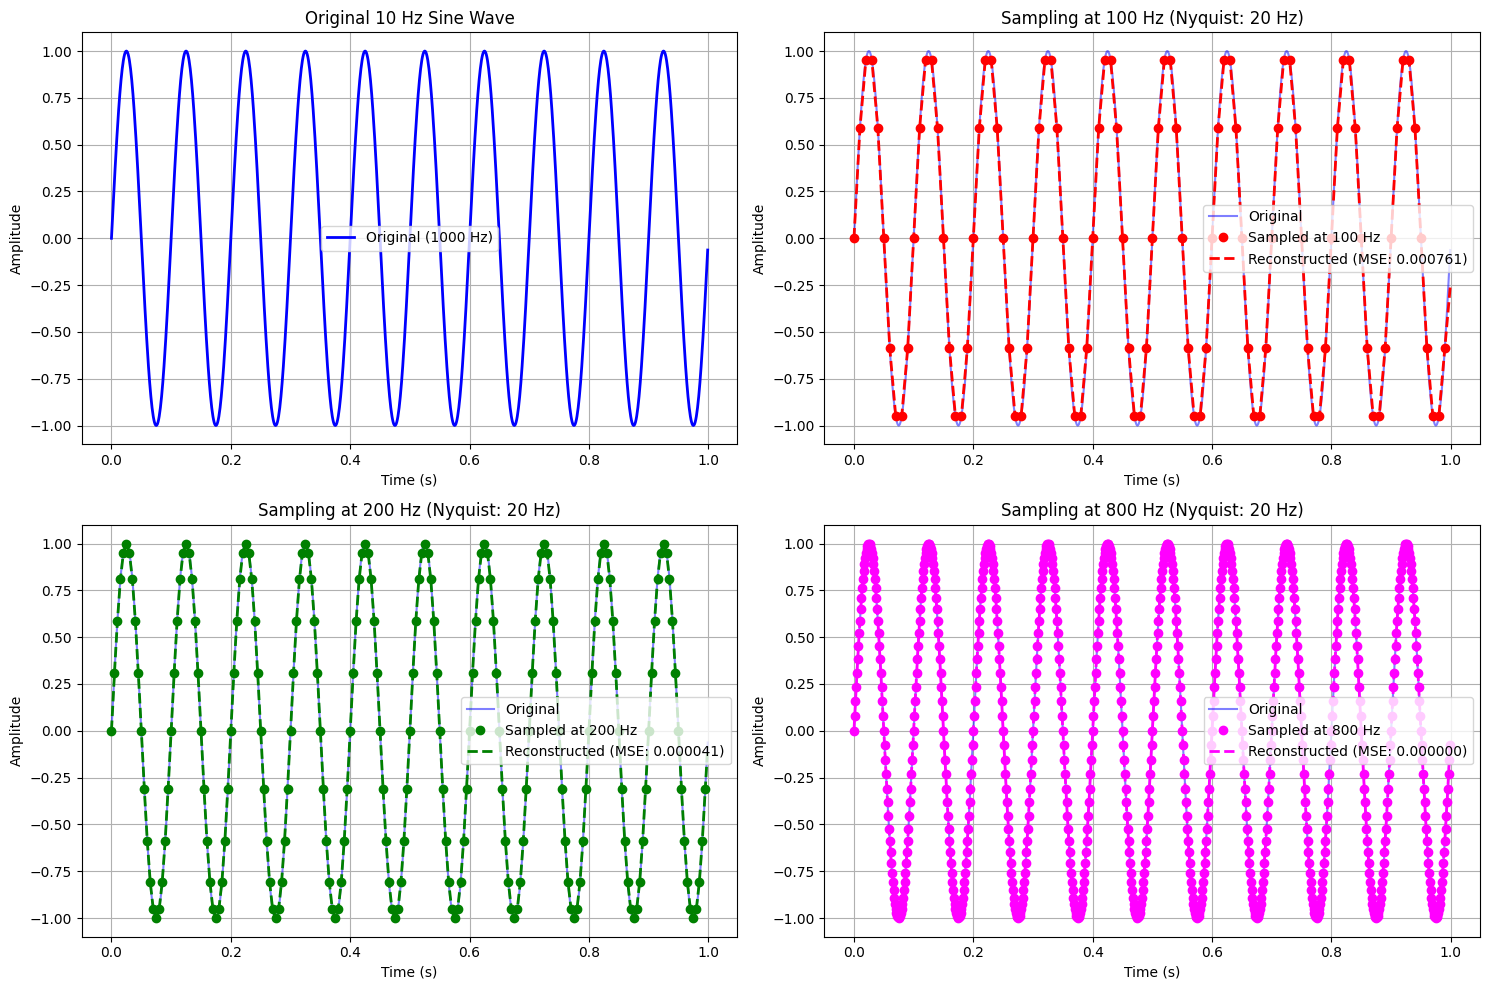


PART 2: LOADING AND CONVERTING AUDIO
✅ Successfully loaded: test.m4a
   Sample Rate: 48000 Hz
   Duration: 2.73 seconds
   Max Amplitude: 0.0505


/tmp/ipython-input-3641248572.py:77: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(audio_path, sr=None)  # Keep original sample rate
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


   Converted and saved as: converted_audio.wav

PART 3: SAMPLING THEOREM ON AUDIO
Sampling rate 12000 Hz (< Nyquist): MSE = 0.00000066
Sampling rate 24000 Hz (= Nyquist): MSE = 0.00000006
Sampling rate 48000 Hz (> Nyquist): MSE = 0.00000000


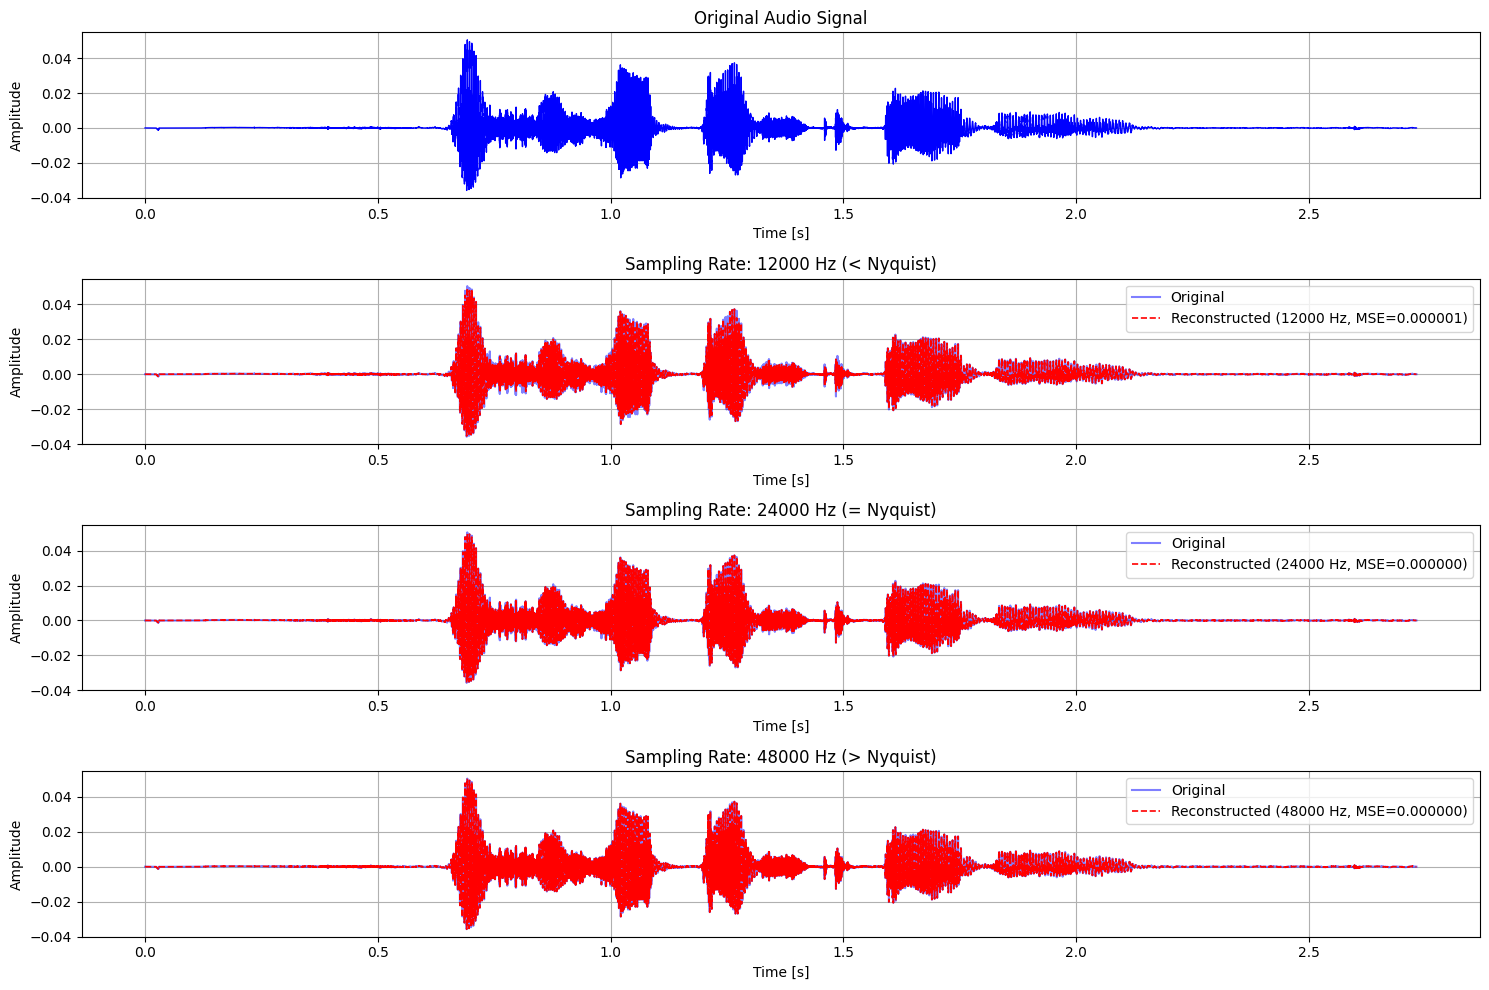


PART 3: SPEECH SAMPLING AND RECONSTRUCTION ANALYSIS
INPUT SIGNAL:
  Sample Rate: 48000 Hz
  Duration: 2.731 seconds
  RMS Energy: 0.005077
  Max Amplitude: 0.050476

OUTPUT COMPARISON:
Rate(Hz) Method   SNR(dB)  Correlation  Quality   
------------------------------------------------------------
Processing 2000 Hz...
  Original length: 131072, Downsampled length: 5462
  t_original length: 131072, t_sampled length: 5462
2000     ZOH      0.75     0.5601       Poor      
2000     Linear   8.48     0.9343       Fair      
Processing 4000 Hz...
  Original length: 131072, Downsampled length: 10923
  t_original length: 131072, t_sampled length: 10923
4000     ZOH      4.01     0.7953       Fair      
4000     Linear   10.01    0.9491       Good      
Processing 8000 Hz...
  Original length: 131072, Downsampled length: 21846
  t_original length: 131072, t_sampled length: 21846
8000     ZOH      8.94     0.9353       Fair      
8000     Linear   14.59    0.9826       Good      
Processing 160

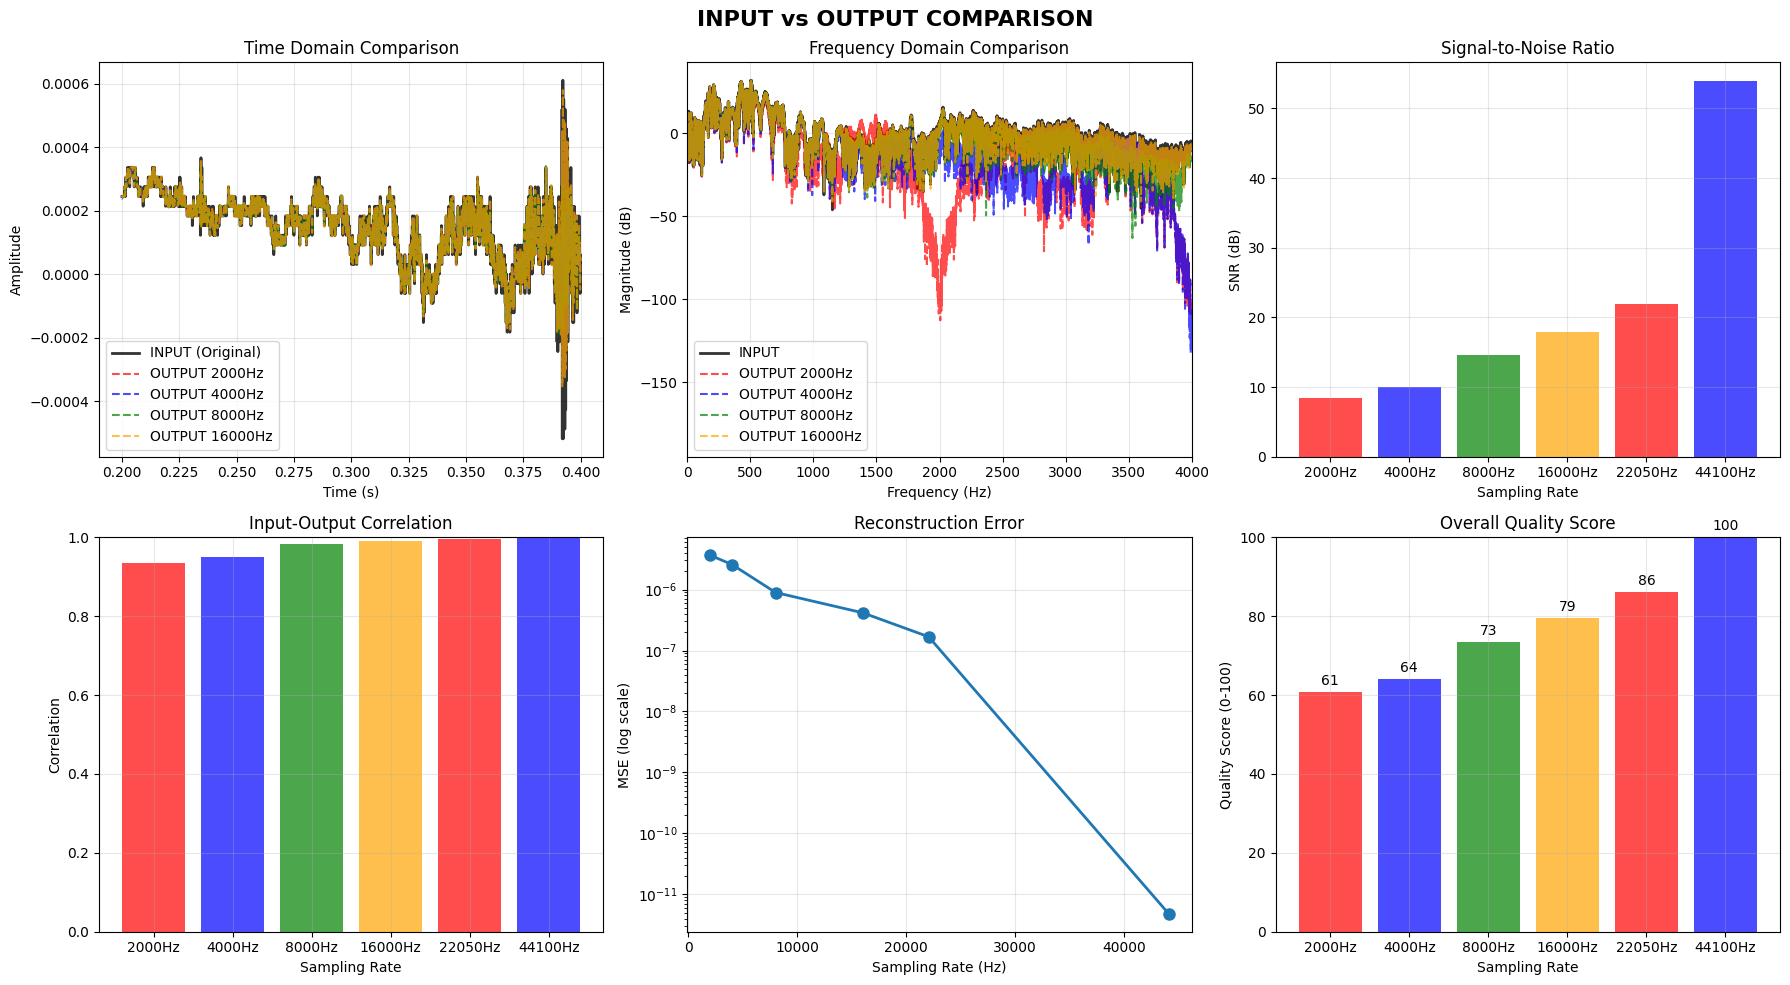


💾 Saving audio files...
   ✅ Saved: input_original.wav
   ✅ Saved: output_zoh_2000Hz.wav and output_linear_2000Hz.wav
   ✅ Saved: output_zoh_4000Hz.wav and output_linear_4000Hz.wav
   ✅ Saved: output_zoh_8000Hz.wav and output_linear_8000Hz.wav
   ✅ Saved: output_zoh_16000Hz.wav and output_linear_16000Hz.wav
   ✅ Saved: output_zoh_22050Hz.wav and output_linear_22050Hz.wav
   ✅ Saved: output_zoh_44100Hz.wav and output_linear_44100Hz.wav
   🎧 You can now listen to and compare the audio files!

PART 7: SOURCE-FILTER MODEL ANALYSIS


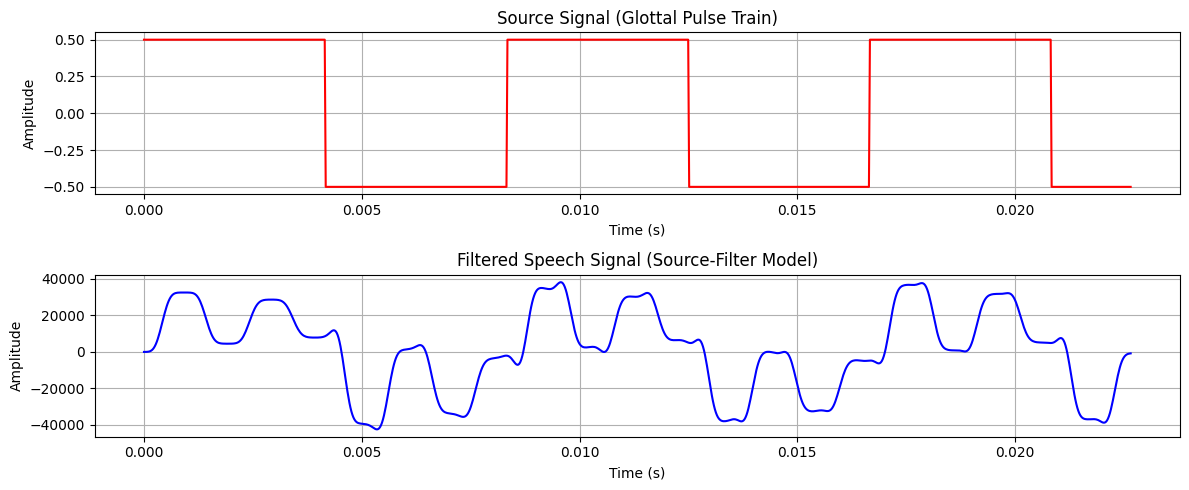


Analyzing at 8000 Hz...
  ZOH:    MSE=33665021.814267, SNR=11.81 dB, Corr=0.967
  Linear: MSE=7780605.263682, SNR=18.17 dB, Corr=0.992

Analyzing at 16000 Hz...
  ZOH:    MSE=3755054.675734, SNR=21.33 dB, Corr=0.996
  Linear: MSE=503473.353984, SNR=30.06 dB, Corr=1.000

Analyzing at 44100 Hz...
  ZOH:    MSE=0.000000, SNR=187.08 dB, Corr=1.000
  Linear: MSE=0.000000, SNR=187.08 dB, Corr=1.000

✅ FULL ANALYSIS COMPLETE!


In [7]:
# ============================================================================
# PART 1: SAMPLING THEOREM WITH SINE WAVE
# ============================================================================

def prove_sampling_theorem():
    """Prove sampling theorem with 10 Hz sine wave"""
    print("=" * 60)
    print("PART 1: SAMPLING THEOREM DEMONSTRATION")
    print("=" * 60)

    # Generate 10 Hz sine wave
    freq = 10
    duration = 1
    fs_original = 1000
    t_original = np.linspace(0, duration, fs_original, endpoint=False)
    sine_original = np.sin(2 * np.pi * freq * t_original)

    # Test sampling frequencies
    sampling_freqs = [100, 200, 800]  # 10x, 20x, 80x Nyquist rate

    plt.figure(figsize=(15, 10))

    # Original signal
    plt.subplot(2, 2, 1)
    plt.plot(t_original, sine_original, 'b-', linewidth=2, label='Original (1000 Hz)')
    plt.title('Original 10 Hz Sine Wave')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.legend()

    colors = ['red', 'green', 'magenta']

    for i, fs in enumerate(sampling_freqs):
        # Sample the signal
        t_sampled = np.arange(0, duration, 1/fs)
        sine_sampled = np.sin(2 * np.pi * freq * t_sampled)

        # Reconstruct using linear interpolation
        f_interp = interp1d(t_sampled, sine_sampled, kind='linear',
                           bounds_error=False, fill_value='extrapolate')
        sine_reconstructed = f_interp(t_original)

        # Calculate error
        mse = np.mean((sine_original - sine_reconstructed)**2)

        # Plot
        plt.subplot(2, 2, i+2)
        plt.plot(t_original, sine_original, 'b-', alpha=0.5, label='Original')
        plt.plot(t_sampled, sine_sampled, 'o', color=colors[i], markersize=6,
                label=f'Sampled at {fs} Hz')
        plt.plot(t_original, sine_reconstructed, '--', color=colors[i], linewidth=2,
                label=f'Reconstructed (MSE: {mse:.6f})')
        plt.title(f'Sampling at {fs} Hz (Nyquist: {2*freq} Hz)')
        plt.xlabel('Time (s)')
        plt.ylabel('Amplitude')
        plt.grid(True)
        plt.legend()

        print(f"Sampling at {fs} Hz: MSE = {mse:.8f}, Nyquist ratio = {fs/(2*freq):.1f}x")

    plt.tight_layout()
    plt.show()

# ============================================================================
# PART 2: AUDIO LOADING AND CONVERSION
# ============================================================================

def load_and_convert_audio(audio_path):
    """Load audio file of any format and convert it"""
    print("\n" + "=" * 60)
    print("PART 2: LOADING AND CONVERTING AUDIO")
    print("=" * 60)

    try:
        # Load audio - librosa can handle most formats (mp3, wav, flac, etc.)
        audio, sr = librosa.load(audio_path, sr=None)  # Keep original sample rate
        print(f"✅ Successfully loaded: {os.path.basename(audio_path)}")
        print(f"   Sample Rate: {sr} Hz")
        print(f"   Duration: {len(audio)/sr:.2f} seconds")
        print(f"   Max Amplitude: {np.max(np.abs(audio)):.4f}")

        # Save as WAV for reference
        output_wav = "converted_audio.wav"
        sf.write(output_wav, audio, sr)
        print(f"   Converted and saved as: {output_wav}")

        return audio, sr

    except Exception as e:
        print(f"❌ Error loading audio: {e}")
        print("📝 Creating synthetic speech-like signal instead...")

        # Generate synthetic speech-like signal
        sr = 8000
        duration = 2.0
        t = np.linspace(0, duration, int(sr * duration))

        # Create speech-like signal with multiple harmonics
        speech_like = (0.5 * np.sin(2 * np.pi * 300 * t) +      # Fundamental
                      0.3 * np.sin(2 * np.pi * 600 * t) +       # 2nd harmonic
                      0.2 * np.sin(2 * np.pi * 900 * t) +       # 3rd harmonic
                      0.1 * np.random.randn(len(t)))            # Noise

        # Apply envelope
        envelope = np.exp(-0.5 * t) * (1 + 0.5 * np.sin(2 * np.pi * 2 * t))
        audio = speech_like * envelope

        print(f"   Generated synthetic signal: {sr} Hz, {duration:.1f}s")
        return audio, sr
#next segment
def prove_audio_sampling_theorem(audio, sr):
    """
    Demonstrate the Sampling Theorem on a real audio signal.
    Uses fs < Nyquist, fs = Nyquist, fs > Nyquist for comparison.
    """
    print("\n" + "=" * 60)
    print("PART 3: SAMPLING THEOREM ON AUDIO")
    print("=" * 60)

    t_original = np.arange(len(audio)) / sr
    max_freq = sr / 2  # Nyquist frequency

    # Choose sampling rates relative to Nyquist
    sampling_rates = [int(max_freq / 2), int(max_freq), int(max_freq * 2)]
    labels = ["< Nyquist", "= Nyquist", "> Nyquist"]

    plt.figure(figsize=(15, 10))

    # Original signal
    plt.subplot(4, 1, 1)
    plt.plot(t_original, audio, 'b', linewidth=1)
    plt.title("Original Audio Signal")
    plt.xlabel("Time [s]")
    plt.ylabel("Amplitude")
    plt.grid(True)

    for i, fs in enumerate(sampling_rates, start=2):
        # Downsample (if fs < original)
        factor = max(1, int(sr / fs))
        sampled = audio[::factor]
        t_sampled = np.arange(len(sampled)) / fs

        # Reconstruct with linear interpolation
        reconstructed = linear_interpolation(sampled, t_original, t_sampled)

        # Calculate MSE
        mse = np.mean((audio - reconstructed) ** 2)

        # Plot
        plt.subplot(4, 1, i)
        plt.plot(t_original, audio, 'b', alpha=0.5, label="Original")
        plt.plot(t_original, reconstructed, '--r', linewidth=1.2, label=f"Reconstructed ({fs} Hz, MSE={mse:.6f})")
        plt.title(f"Sampling Rate: {fs} Hz ({labels[i-2]})")
        plt.xlabel("Time [s]")
        plt.ylabel("Amplitude")
        plt.grid(True)
        plt.legend()

        print(f"Sampling rate {fs} Hz ({labels[i-2]}): MSE = {mse:.8f}")

    plt.tight_layout()
    plt.show()

# ============================================================================
# PART 3: RECONSTRUCTION FUNCTIONS
# ============================================================================

def zero_order_hold(samples, t_original, t_sampled):
    """Zero-order hold reconstruction"""
    reconstructed = np.zeros_like(t_original)
    for i, t in enumerate(t_original):
        idx = np.where(t_sampled <= t)[0]
        if len(idx) > 0:
            reconstructed[i] = samples[idx[-1]]
        else:
            reconstructed[i] = samples[0]
    return reconstructed

def linear_interpolation(samples, t_original, t_sampled):
    """Linear interpolation reconstruction"""
    f_interp = interp1d(t_sampled, samples, kind='linear',
                       bounds_error=False, fill_value='extrapolate')
    return f_interp(t_original)

def calculate_metrics(original, reconstructed):
    """Calculate similarity metrics"""
    mse = np.mean((original - reconstructed)**2)
    signal_power = np.mean(original**2)
    noise_power = mse
    snr_db = 10 * np.log10(signal_power / (noise_power + 1e-10))
    correlation = np.corrcoef(original, reconstructed)[0, 1]

    return {'MSE': mse, 'SNR_dB': snr_db, 'Correlation': correlation}

# ============================================================================
# PART 4: MAIN SPEECH ANALYSIS
# ============================================================================

def analyze_speech_sampling(audio, sr_original, sampling_rates=[2000, 4000, 8000, 16000, 22050, 44100]):
    """Analyze speech sampling and reconstruction"""
    print("\n" + "=" * 60)
    print("PART 3: SPEECH SAMPLING AND RECONSTRUCTION ANALYSIS")
    print("=" * 60)

    # Original signal properties
    print(f"INPUT SIGNAL:")
    print(f"  Sample Rate: {sr_original} Hz")
    print(f"  Duration: {len(audio)/sr_original:.3f} seconds")
    print(f"  RMS Energy: {np.sqrt(np.mean(audio**2)):.6f}")
    print(f"  Max Amplitude: {np.max(np.abs(audio)):.6f}")

    duration = len(audio) / sr_original
    t_original = np.linspace(0, duration, len(audio))

    results = {}

    print(f"\nOUTPUT COMPARISON:")
    print(f"{'Rate(Hz)':<8} {'Method':<8} {'SNR(dB)':<8} {'Correlation':<12} {'Quality':<10}")
    print("-" * 60)

    # Process each sampling rate
    for fs in sampling_rates:
        print(f"Processing {fs} Hz...")

        # Downsample with anti-aliasing
        if fs < sr_original:
            nyquist = fs / 2
            b, a = signal.butter(4, nyquist / (sr_original / 2), btype='low')
            filtered_audio = signal.filtfilt(b, a, audio)
            downsample_factor = int(sr_original / fs)
            downsampled = filtered_audio[::downsample_factor]
        else:
            downsampled = audio.copy()
            downsample_factor = 1

        # Create proper time vectors
        # For downsampled signal
        t_sampled = np.linspace(0, duration, len(downsampled))

        # Debug prints
        print(f"  Original length: {len(audio)}, Downsampled length: {len(downsampled)}")
        print(f"  t_original length: {len(t_original)}, t_sampled length: {len(t_sampled)}")

        # Make sure arrays are compatible
        if len(t_sampled) != len(downsampled):
            print(f"  Fixing array length mismatch...")
            min_len = min(len(t_sampled), len(downsampled))
            t_sampled = t_sampled[:min_len]
            downsampled = downsampled[:min_len]

        try:
            # Reconstruct
            zoh_reconstructed = zero_order_hold(downsampled, t_original, t_sampled)
            linear_reconstructed = linear_interpolation(downsampled, t_original, t_sampled)

            # Calculate metrics
            zoh_metrics = calculate_metrics(audio, zoh_reconstructed)
            linear_metrics = calculate_metrics(audio, linear_reconstructed)

            # Quality assessment
            def assess_quality(snr, corr):
                if snr > 20 and corr > 0.95: return "Excellent"
                elif snr > 10 and corr > 0.85: return "Good"
                elif snr > 0 and corr > 0.70: return "Fair"
                else: return "Poor"

            quality_zoh = assess_quality(zoh_metrics['SNR_dB'], zoh_metrics['Correlation'])
            quality_linear = assess_quality(linear_metrics['SNR_dB'], linear_metrics['Correlation'])

            print(f"{fs:<8} {'ZOH':<8} {zoh_metrics['SNR_dB']:<8.2f} {zoh_metrics['Correlation']:<12.4f} {quality_zoh:<10}")
            print(f"{fs:<8} {'Linear':<8} {linear_metrics['SNR_dB']:<8.2f} {linear_metrics['Correlation']:<12.4f} {quality_linear:<10}")

            results[fs] = {
                'ZOH': zoh_reconstructed,
                'Linear': linear_reconstructed,
                'ZOH_metrics': zoh_metrics,
                'Linear_metrics': linear_metrics
            }

        except Exception as e:
            print(f"  ❌ Error processing {fs} Hz: {e}")
            continue

    return results

# ============================================================================
# PART 5: VISUALIZATION
# ============================================================================

def plot_comparison(audio, sr, results, sampling_rates):
    """Plot input vs output comparison"""
    print(f"\n📊 Creating comparison plots...")

    duration = len(audio) / sr
    t_original = np.linspace(0, duration, len(audio))

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('INPUT vs OUTPUT COMPARISON', fontsize=16, fontweight='bold')

    colors = ['red', 'blue', 'green', 'orange']

    # Plot 1: Time domain (zoomed)
    start_idx = int(0.2 * sr) if len(audio) > int(0.4 * sr) else 0
    end_idx = int(0.4 * sr) if len(audio) > int(0.4 * sr) else len(audio)

    axes[0, 0].plot(t_original[start_idx:end_idx], audio[start_idx:end_idx],
                   'black', linewidth=2, label='INPUT (Original)', alpha=0.8)

    for i, (fs, color) in enumerate(zip(sampling_rates[:4], colors)):
        if fs in results:
            reconstructed = results[fs]['Linear']
            axes[0, 0].plot(t_original[start_idx:end_idx], reconstructed[start_idx:end_idx],
                           '--', color=color, linewidth=1.5, alpha=0.7, label=f'OUTPUT {fs}Hz')

    axes[0, 0].set_title('Time Domain Comparison')
    axes[0, 0].set_xlabel('Time (s)')
    axes[0, 0].set_ylabel('Amplitude')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Plot 2: Frequency domain
    freqs = np.fft.fftfreq(len(audio), 1/sr)[:len(audio)//2]
    fft_orig = np.abs(np.fft.fft(audio))[:len(audio)//2]

    axes[0, 1].plot(freqs, 20*np.log10(fft_orig + 1e-10), 'black', linewidth=2,
                   label='INPUT', alpha=0.8)

    for i, (fs, color) in enumerate(zip(sampling_rates[:4], colors)):
        if fs in results:
            reconstructed = results[fs]['Linear']
            fft_recon = np.abs(np.fft.fft(reconstructed))[:len(reconstructed)//2]
            freqs_recon = np.fft.fftfreq(len(reconstructed), 1/sr)[:len(reconstructed)//2]
            axes[0, 1].plot(freqs_recon, 20*np.log10(fft_recon + 1e-10), '--',
                           color=color, linewidth=1.5, alpha=0.7, label=f'OUTPUT {fs}Hz')

    axes[0, 1].set_title('Frequency Domain Comparison')
    axes[0, 1].set_xlabel('Frequency (Hz)')
    axes[0, 1].set_ylabel('Magnitude (dB)')
    axes[0, 1].set_xlim(0, min(4000, sr/2))
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Plot 3: SNR comparison
    snr_values = [results[fs]['Linear_metrics']['SNR_dB'] for fs in sampling_rates if fs in results]
    axes[0, 2].bar(range(len(snr_values)), snr_values, color=colors[:len(snr_values)], alpha=0.7)
    axes[0, 2].set_title('Signal-to-Noise Ratio')
    axes[0, 2].set_xlabel('Sampling Rate')
    axes[0, 2].set_ylabel('SNR (dB)')
    axes[0, 2].set_xticks(range(len(sampling_rates)))
    axes[0, 2].set_xticklabels([f'{fs}Hz' for fs in sampling_rates if fs in results])
    axes[0, 2].grid(True, alpha=0.3)

    # Plot 4: Correlation comparison
    corr_values = [results[fs]['Linear_metrics']['Correlation'] for fs in sampling_rates if fs in results]
    axes[1, 0].bar(range(len(corr_values)), corr_values, color=colors[:len(corr_values)], alpha=0.7)
    axes[1, 0].set_title('Input-Output Correlation')
    axes[1, 0].set_xlabel('Sampling Rate')
    axes[1, 0].set_ylabel('Correlation')
    axes[1, 0].set_xticks(range(len(sampling_rates)))
    axes[1, 0].set_xticklabels([f'{fs}Hz' for fs in sampling_rates if fs in results])
    axes[1, 0].set_ylim(0, 1)
    axes[1, 0].grid(True, alpha=0.3)

    # Plot 5: Error analysis
    mse_values = [results[fs]['Linear_metrics']['MSE'] for fs in sampling_rates if fs in results]
    axes[1, 1].semilogy([fs for fs in sampling_rates if fs in results], mse_values, 'o-',
                        linewidth=2, markersize=8)
    axes[1, 1].set_title('Reconstruction Error')
    axes[1, 1].set_xlabel('Sampling Rate (Hz)')
    axes[1, 1].set_ylabel('MSE (log scale)')
    axes[1, 1].grid(True, alpha=0.3)

    # Plot 6: Quality summary
    quality_scores = []
    for fs in sampling_rates:
        if fs in results:
            corr = results[fs]['Linear_metrics']['Correlation']
            snr = results[fs]['Linear_metrics']['SNR_dB']
            # Simple quality score
            quality_score = (corr * 50) + (min(snr, 30) / 30 * 50)
            quality_scores.append(quality_score)

    bars = axes[1, 2].bar(range(len(quality_scores)), quality_scores,
                         color=colors[:len(quality_scores)], alpha=0.7)
    axes[1, 2].set_title('Overall Quality Score')
    axes[1, 2].set_xlabel('Sampling Rate')
    axes[1, 2].set_ylabel('Quality Score (0-100)')
    axes[1, 2].set_xticks(range(len(sampling_rates)))
    axes[1, 2].set_xticklabels([f'{fs}Hz' for fs in sampling_rates if fs in results])
    axes[1, 2].set_ylim(0, 100)
    axes[1, 2].grid(True, alpha=0.3)

    # Add quality score labels on bars
    for bar, score in zip(bars, quality_scores):
        height = bar.get_height()
        axes[1, 2].text(bar.get_x() + bar.get_width()/2., height + 1, f'{score:.0f}',
                        ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

# ============================================================================
# PART 6: SAVE AUDIO FILES
# ============================================================================

def save_audio_outputs(audio, sr, results):
    """Save input and output audio files"""
    print(f"\n💾 Saving audio files...")

    # Save original
    sf.write("input_original.wav", audio, sr)
    print(f"   ✅ Saved: input_original.wav")

    # Save reconstructed versions
    for fs in results.keys():
        sf.write(f"output_zoh_{fs}Hz.wav", results[fs]['ZOH'], sr)
        sf.write(f"output_linear_{fs}Hz.wav", results[fs]['Linear'], sr)
        print(f"   ✅ Saved: output_zoh_{fs}Hz.wav and output_linear_{fs}Hz.wav")

    print(f"   🎧 You can now listen to and compare the audio files!")

# ============================================================================
# PART 7: SOURCE-FILTER MODEL ANALYSIS
# ============================================================================

def source_filter_model_analysis():
    """Implement Source-Filter model and analyze sampling & reconstruction"""
    print("\n" + "=" * 60)
    print("PART 7: SOURCE-FILTER MODEL ANALYSIS")
    print("=" * 60)

    sr = 44100  # original "high-quality" sampling rate
    duration = 1.0
    t = np.linspace(0, duration, int(sr * duration))

    # ----- Source signals -----
    # Voiced: simple glottal pulse train
    f0 = 120  # pitch frequency in Hz
    pulse_train = signal.square(2 * np.pi * f0 * t) * 0.5

    # Unvoiced: white noise
    noise = np.random.randn(len(t)) * 0.1

    # Choose voiced source for analysis (can mix with noise for unvoiced)
    source = pulse_train

    # ----- Vocal tract filter -----
    # Example: simple 3-formant all-pole filter (approximate formants)
    formants = [500, 1500, 2500]  # Hz
    bandwidths = [50, 70, 100]    # Hz

    # Create filter coefficients
    a = np.array([1.0])
    for f, bw in zip(formants, bandwidths):
        r = np.exp(-np.pi * bw / sr)
        theta = 2 * np.pi * f / sr
        a = np.convolve(a, [1, -2 * r * np.cos(theta), r ** 2])

    # Filter the source through vocal tract
    speech = signal.lfilter([1.0], a, source)

    # ----- Plot original source vs filtered speech -----
    plt.figure(figsize=(12, 5))
    plt.subplot(2, 1, 1)
    plt.plot(t[:1000], source[:1000], 'r')
    plt.title("Source Signal (Glottal Pulse Train)")
    plt.xlabel("Time (s)"); plt.ylabel("Amplitude")
    plt.grid(True)

    plt.subplot(2, 1, 2)
    plt.plot(t[:1000], speech[:1000], 'b')
    plt.title("Filtered Speech Signal (Source-Filter Model)")
    plt.xlabel("Time (s)"); plt.ylabel("Amplitude")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ----- Sampling and reconstruction -----
    sampling_rates = [8000, 16000, 44100]
    results = {}

    for fs in sampling_rates:
        print(f"\nAnalyzing at {fs} Hz...")

        # Downsample with anti-aliasing if needed
        if fs < sr:
            nyquist = fs / 2
            b, a_filt = signal.butter(4, nyquist / (sr / 2), btype='low')
            filtered = signal.filtfilt(b, a_filt, speech)
            factor = int(sr / fs)
            downsampled = filtered[::factor]
        else:
            downsampled = speech.copy()
            factor = 1

        t_sampled = np.linspace(0, duration, len(downsampled))

        # Reconstruct
        zoh_recon = zero_order_hold(downsampled, t, t_sampled)
        lin_recon = linear_interpolation(downsampled, t, t_sampled)

        # Metrics
        zoh_metrics = calculate_metrics(speech, zoh_recon)
        lin_metrics = calculate_metrics(speech, lin_recon)

        print(f"  ZOH:    MSE={zoh_metrics['MSE']:.6f}, SNR={zoh_metrics['SNR_dB']:.2f} dB, Corr={zoh_metrics['Correlation']:.3f}")
        print(f"  Linear: MSE={lin_metrics['MSE']:.6f}, SNR={lin_metrics['SNR_dB']:.2f} dB, Corr={lin_metrics['Correlation']:.3f}")

        results[fs] = {
            'ZOH': zoh_recon,
            'Linear': lin_recon,
            'ZOH_metrics': zoh_metrics,
            'Linear_metrics': lin_metrics
        }


    return results

# ============================================================================
# MAIN EXECUTION (extended)
# ============================================================================

# Step 1: Prove sampling theorem
prove_sampling_theorem()

# Step 2: Load your audio file
audio_file = "/content/test.m4a"  # Change if needed
audio, sr = load_and_convert_audio(audio_file)

# ✅ Add this line right after loading the audio
prove_audio_sampling_theorem(audio, sr)

# Step 3: Analyze different sampling rates
sampling_rates = [2000, 4000, 8000, 16000, 22050, 44100]  # ✅ now includes 44100
results = analyze_speech_sampling(audio, sr, sampling_rates)

# Step 4: Create comparison plots
plot_comparison(audio, sr, results, sampling_rates)

# Step 5: Save audio files for listening comparison
save_audio_outputs(audio, sr, results)

# Step 6: Source-Filter model analysis
sf_results = source_filter_model_analysis()

print("\n" + "="*60)
print("✅ FULL ANALYSIS COMPLETE!")
print("="*60)